# Pr?ctica: Regresi?n Log?stica para Clasificacion

## Objetivo

El objetivo de esta practica es entrenar un modelo de **regresi?n log?stica** para predecir si un estudiante aprobara un examen bas?ndonos en las horas de estudio.

La variable de entrada ser?:

- `horas_estudiadas`: n?mero de horas que estudio cada estudiante.

La variable de salida ser?:

- `resultado_examen`: 0 si no aprob?, 1 si aprob?.

## Paso 1: Importar librer?as

Usamos NumPy para manejar arrays num?ricos, Pandas para crear tablas, Matplotlib para graficar y Scikit-learn para entrenar el modelo de regresi?n log?stica.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

plt.style.use("seaborn-v0_8-whitegrid")

## Paso 2: Crear un dataset ficticio

Creamos datos simulados donde se observa una relaci?n sencilla: los estudiantes que estudian m?s horas suelen aprobar.

In [2]:
horas_estudiadas = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
resultado_examen = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

datos = pd.DataFrame({
    "Horas estudiadas": horas_estudiadas,
    "Resultado examen": resultado_examen
})

datos

,Horas estudiadas,Resultado examen
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1
9,10,1


## Paso 3: Visualizar los datos iniciales

Antes de entrenar el modelo, observamos los datos reales.

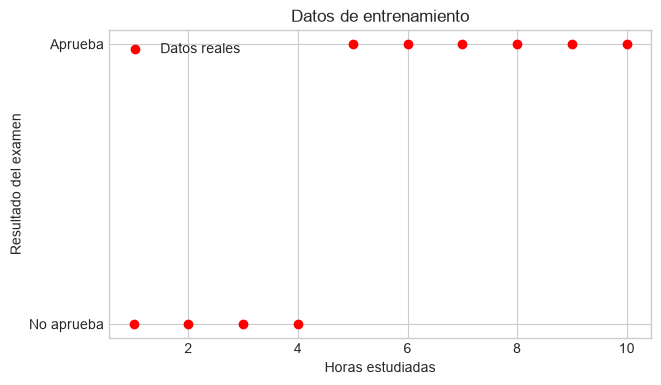

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(horas_estudiadas, resultado_examen, color="red", label="Datos reales")
plt.xlabel("Horas estudiadas")
plt.ylabel("Resultado del examen")
plt.title("Datos de entrenamiento")
plt.yticks([0, 1], ["No aprueba", "Aprueba"])
plt.legend()
plt.show()

## Paso 4: Entrenar el modelo

Scikit-learn espera que las variables de entrada tengan formato de matriz. Por eso usamos `reshape(-1, 1)`, que convierte el array de horas en una columna.

In [4]:
X = horas_estudiadas.reshape(-1, 1)
y = resultado_examen

modelo = LogisticRegression()
modelo.fit(X, y)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## Paso 5: Predecir probabilidades

La regresi?n log?stica no solo predice una clase, tambi?n calcula la probabilidad de pertenecer a cada clase. En este caso nos interesa la probabilidad de aprobar.

In [5]:
horas_nuevas = np.linspace(0, 12, 1000).reshape(-1, 1)
probabilidades = modelo.predict_proba(horas_nuevas)[:, 1]

probabilidades[:10]

array([0.00490944, 0.00497929, 0.00505013, 0.00512197, 0.00519482,
       0.00526871, 0.00534365, 0.00541964, 0.00549671, 0.00557487])

## Paso 6: Visualizar la curva sigmoide

La l?nea azul representa la probabilidad estimada de aprobar seg?n las horas estudiadas.

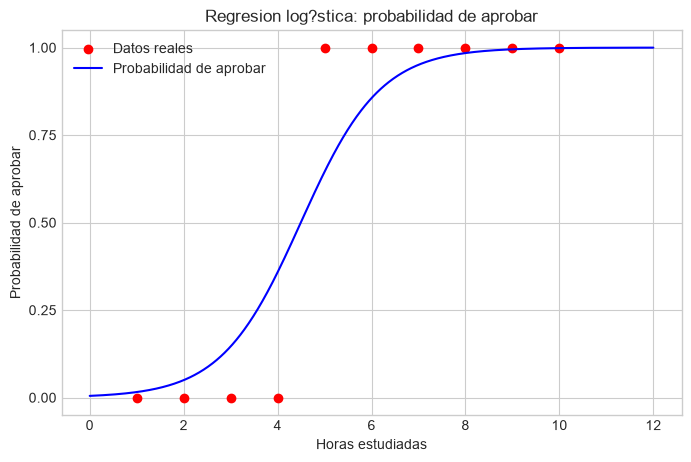

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(horas_estudiadas, resultado_examen, color="red", label="Datos reales")
plt.plot(horas_nuevas, probabilidades, color="blue", label="Probabilidad de aprobar")
plt.xlabel("Horas estudiadas")
plt.ylabel("Probabilidad de aprobar")
plt.title("Regresion log?stica: probabilidad de aprobar")
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.legend()
plt.show()

## Paso 7: Examinar los coeficientes

El intercepto y el coeficiente indican c?mo el modelo relaci?na las horas de estudio con la probabilidad de aprobar.

In [7]:
print("Intercepto:", modelo.intercept_[0])
print("Coeficiente:", modelo.coef_[0][0])

Intercepto: -5.311674343465787
Coeficiente: 1.181949430069053


## Paso 8: Crear una tabla con probabilidades

Calculamos la probabilidad de aprobar para cada estudiante del dataset original.

In [8]:
probabilidades_originales = modelo.predict_proba(X)[:, 1]
predicciones = modelo.predict(X)

tabla_resultados = pd.DataFrame({
    "Horas estudiadas": horas_estudiadas,
    "Resultado real": resultado_examen,
    "Probabilidad de aprobar": probabilidades_originales,
    "Predicci?n del modelo": predicciones
})

tabla_resultados

,Horas estudiadas,Resultado real,Probabilidad de aprobar,Predicci?n del modelo
0,1,0,0.015833,0
1,2,0,0.049842,0
2,3,0,0.146062,0
3,4,0,0.358041,0
4,5,1,0.645215,1
5,6,1,0.855700,1
6,7,1,0.950826,1
7,8,1,0.984387,1
8,9,1,0.995159,1
9,10,1,0.998510,1


## Paso 9: Evaluar el modelo

Evaluamos el rendimiento del modelo usando m?tricas de clasificaci?n: accuracy, matriz de confusion, precisi?n, recall, F1-score y ROC-AUC.

In [9]:
accuracy = accuracy_score(y, predicciones)
matriz = confusion_matrix(y, predicciones)
auc = roc_auc_score(y, probabilidades_originales)

print("Accuracy:", accuracy)
print("ROC-AUC:", auc)
print("Matriz de confusi?n:")
print(matriz)
print("\nReporte de clasificaci?n:")
print(classification_report(y, predicciones, target_names=["No aprueba", "Aprueba"]))

Accuracy: 1.0
ROC-AUC: 1.0
Matriz de confusi?n:
[[4 0]
 [0 6]]

Reporte de clasificaci?n:
              precision    recall  f1-score   support

  No aprueba       1.00      1.00      1.00         4
     Aprueba       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## Paso 10: Curva ROC

La curva ROC permite analizar c?mo cambia el rendimiento del modelo al modificar el umbral de decisi?n.

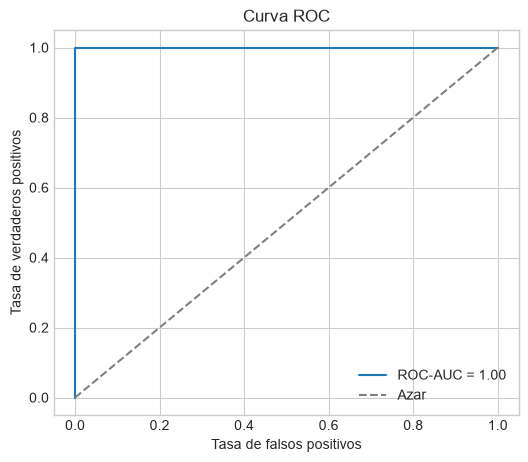

In [10]:
fpr, tpr, thresholds = roc_curve(y, probabilidades_originales)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

## Paso 11: Segundo ejemplo con variabilidad

En la vida real los datos no suelen ser perfectos. Algunos estudiantes pueden estudiar muchas horas y suspender, mientras que otros pueden aprobar con menos horas.

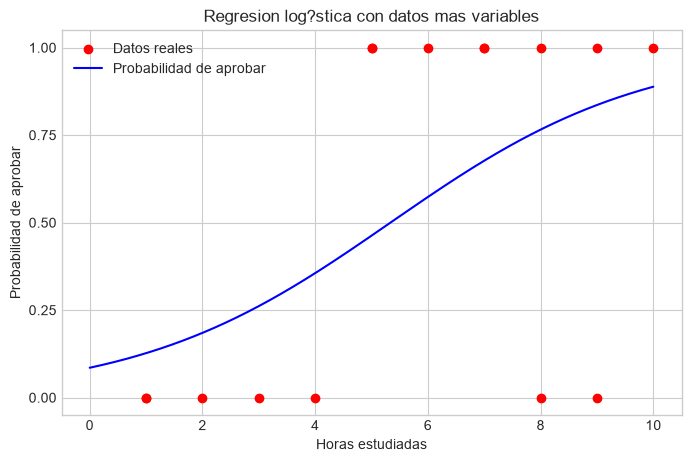

In [11]:
horas_estudiadas_var = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1, 8, 5, 7, 9])
resultado_examen_var = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0])

X_var = horas_estudiadas_var.reshape(-1, 1)
y_var = resultado_examen_var

modelo_var = LogisticRegression()
modelo_var.fit(X_var, y_var)

horas_nuevas_var = np.linspace(0, 10, 1000).reshape(-1, 1)
probabilidades_var = modelo_var.predict_proba(horas_nuevas_var)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(horas_estudiadas_var, resultado_examen_var, color="red", label="Datos reales")
plt.plot(horas_nuevas_var, probabilidades_var, color="blue", label="Probabilidad de aprobar")
plt.xlabel("Horas estudiadas")
plt.ylabel("Probabilidad de aprobar")
plt.title("Regresion log?stica con datos mas variables")
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.legend()
plt.show()

## Paso 12: Interpretaci?n final

La regresi?n log?stica permite resolver problemas de clasificaci?n binaria calculando probabilidades. En este caso, el modelo aprende que a mayor n?mero de horas estudiadas, mayor suele ser la probabilidad de aprobar.

Cuando los datos son ideales, la separacion entre clases es mas clara. Cuando hay variabilidad, el modelo sigue siendo util, pero la probabilidad cambia de forma menos brusca y existe mas incertidumbre.

Este ejercicio muestra que los modelos de clasificaci?n no dan verdades absolutas: ofrecen predicciones basadas en patrones aprendidos a partir de datos.